# 1. Import Library


---



In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import wilcoxon # Untuk uji statistik
import warnings
import time
warnings.filterwarnings('ignore')
np.random.seed(42)

print("Library, TimeSeriesSplit, dan Random Seed dimuat!")

Library, TimeSeriesSplit, dan Random Seed dimuat!


# 2. Load Data & Feature Engineering

---



In [ ]:
# LOAD DATA

file_path = 'DATA_PENDAPATAN_PARKIR_PER_HARI_2022-2025.csv'
df = pd.read_csv(file_path, parse_dates=['Tanggal'])

# [UPGRADE 2]: Tambahkan Lag Features (Ingatan masa lalu untuk SVR)
df['Lag_1'] = df['Total_Pendapatan'].shift(1) # Pendapatan 1 hari lalu
df['Lag_7'] = df['Total_Pendapatan'].shift(7) # Pendapatan 1 minggu lalu

# Karena shift membuat baris awal menjadi kosong (NaN), kita drop
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("✅ CELL 2 BERHASIL: Fitur Lag 1 dan Lag 7 berhasil ditambahkan!")
print(f"Total baris data setelah drop NaN: {len(df)}")
display(df[['Tanggal', 'Total_Pendapatan', 'Lag_1', 'Lag_7']].head(5))

✅ CELL 2 BERHASIL: Fitur Lag 1 dan Lag 7 berhasil ditambahkan!
Total baris data setelah drop NaN: 1289


,Tanggal,Total_Pendapatan,Lag_1,Lag_7
0,2022-01-09,14277000,11734333.0,2699000.0
1,2022-01-10,6663500,14277000.0,6618500.0
2,2022-01-11,6837000,6663500.0,6625500.0
3,2022-01-12,6807000,6837000.0,6451000.0
4,2022-01-13,6893500,6807000.0,6649000.0


# 3. Split Data (Berdasarkan Tahun)

---



In [ ]:
# FITUR DAN TARGET (Sekarang pakai 7 Fitur)
fitur = ['Tahun', 'Bulan', 'Tanggal_Kalender', 'Hari_dalam_Minggu', 'Libur_Nasional', 'Lag_1', 'Lag_7']
target = 'Total_Pendapatan'

# SPLIT DATA
df_train = df[df['Tahun'] <= 2024].copy()
df_test = df[df['Tahun'] == 2025].copy()

X_train_raw = df_train[fitur].values
y_train_raw = df_train[target].values.reshape(-1, 1)

X_test_raw = df_test[fitur].values
y_test_raw = df_test[target].values.reshape(-1, 1)

print("Data berhasil dibagi!")

Data berhasil dibagi!


# 4. Preprocessing (Normalisasi)

---



In [ ]:
# NORMALISASI MIN-MAX SCALER
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train_raw)
y_train = scaler_y.fit_transform(y_train_raw).ravel()

X_test = scaler_X.transform(X_test_raw)
y_test = scaler_y.transform(y_test_raw).ravel()
y_test_asli = y_test_raw.flatten()

# [UPGRADE 3]: Simpan juga y_train_asli untuk cek Overfitting
y_train_asli = y_train_raw.flatten()

print("7 Fitur berhasil dinormalisasi!")

7 Fitur berhasil dinormalisasi!


# 5. Model 1 - SVR Baseline (Default)

---



In [ ]:
print("="*50)
print(" MULAI TRAINING SVR BASELINE")
print("="*50)

start_time = time.time()

# [UPGRADE MINOR 1]: Parameter baseline ditulis sangat eksplisit (sesuai default Scikit-Learn)
svr_baseline = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale', verbose=True)
svr_baseline.fit(X_train, y_train)

lama_waktu_base = time.time() - start_time

# Prediksi Train & Test (Untuk cek Overfitting)
y_pred_base_train = scaler_y.inverse_transform(svr_baseline.predict(X_train).reshape(-1, 1)).flatten()
y_pred_base_test = scaler_y.inverse_transform(svr_baseline.predict(X_test).reshape(-1, 1)).flatten()

print(f"\n SVR Baseline Selesai dalam {lama_waktu_base:.2f} detik.")
print("Parameter yang digunakan: C=1.0, epsilon=0.1, gamma='scale'")

 MULAI TRAINING SVR BASELINE
[LibSVM]
 SVR Baseline Selesai dalam 0.02 detik.
Parameter yang digunakan: C=1.0, epsilon=0.1, gamma='scale'


# 6. Model 2 - SVR + Grid Search

---




In [ ]:
print("="*50)
print(" MULAI TRAINING SVR + GRID SEARCH")
print("="*50)

tscv = TimeSeriesSplit(n_splits=3)

# Ruang Pencarian Parameter
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.001, 0.01, 0.1, 0.5],
    'gamma': [0.001, 0.01, 0.1, 1]
}

start_time = time.time()
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
lama_waktu_gs = time.time() - start_time

svr_gs = grid_search.best_estimator_

y_pred_gs_train = scaler_y.inverse_transform(svr_gs.predict(X_train).reshape(-1, 1)).flatten()
y_pred_gs_test = scaler_y.inverse_transform(svr_gs.predict(X_test).reshape(-1, 1)).flatten()

print(f"\nGrid Search Selesai dalam {lama_waktu_gs:.2f} detik.")
print(f"Parameter Terbaik (Peringkat 1): {grid_search.best_params_}\n")

# [UPGRADE DETAIL]: Tampilkan 3 Kombinasi Parameter Terbaik
results = pd.DataFrame(grid_search.cv_results_)
top3 = results.nsmallest(3, 'rank_test_score')[['params', 'mean_test_score', 'rank_test_score']]
print("TOP 3 KOMBINASI GRID SEARCH:")
for index, row in top3.iterrows():
    print(f"Rank {row['rank_test_score']} | Score (Neg MSE): {row['mean_test_score']:.5f} | Params: {row['params']}")

 MULAI TRAINING SVR + GRID SEARCH
Fitting 3 folds for each of 64 candidates, totalling 192 fits

Grid Search Selesai dalam 18.26 detik.
Parameter Terbaik (Peringkat 1): {'C': 10, 'epsilon': 0.01, 'gamma': 1}

TOP 3 KOMBINASI GRID SEARCH:
Rank 1 | Score (Neg MSE): -0.00958 | Params: {'C': 10, 'epsilon': 0.01, 'gamma': 1}
Rank 2 | Score (Neg MSE): -0.01044 | Params: {'C': 10, 'epsilon': 0.001, 'gamma': 1}
Rank 3 | Score (Neg MSE): -0.01099 | Params: {'C': 1, 'epsilon': 0.01, 'gamma': 1}


# 7. Model 3 - SVR + Grey Wolf Optimizer (GWO)

---



In [ ]:
print("="*50)
print(" MULAI TRAINING SVR + GWO")
print("="*50)

# [UPGRADE 5]: GWO mencari parameter dalam Log-Scale (10^x)
def fitness_function(params):
    C_val = 10 ** params[0]
    eps_val = 10 ** params[1]
    gamma_val = 10 ** params[2]

    model = SVR(kernel='rbf', C=C_val, epsilon=eps_val, gamma=gamma_val)
    tscv = TimeSeriesSplit(n_splits=3)
    mse = cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_mean_squared_error')
    return -mse.mean()

num_wolves = 20 # DITINGKATKAN
max_iter = 50 # DITINGKATKAN
dim = 3
# Batas Pangkat (Eksponen): C[10^-2, 10^3], Eps[10^-3, 10^0], Gamma[10^-4, 10^1]
lb = np.array([-2.0, -3.0, -4.0])
ub = np.array([3.0, 0.0, 1.0])

positions = np.random.uniform(0, 1, (num_wolves, dim)) * (ub - lb) + lb
alpha_pos, beta_pos, delta_pos = np.zeros(dim), np.zeros(dim), np.zeros(dim)
alpha_score, beta_score, delta_score = float("inf"), float("inf"), float("inf")
convergence_curve = []

start_time = time.time()
for t in range(max_iter):
    for i in range(num_wolves):
        fitness = fitness_function(positions[i])
        if fitness < alpha_score:
            delta_score, delta_pos = beta_score, beta_pos.copy()
            beta_score, beta_pos = alpha_score, alpha_pos.copy()
            alpha_score, alpha_pos = fitness, positions[i].copy()
        elif fitness < beta_score:
            delta_score, delta_pos = beta_score, beta_pos.copy()
            beta_score, beta_pos = fitness, positions[i].copy()
        elif fitness < delta_score:
            delta_score, delta_pos = fitness, positions[i].copy()

    a = 2 - t * (2 / max_iter)
    for i in range(num_wolves):
        for j in range(dim):
            r1, r2 = np.random.rand(), np.random.rand()
            A1, C1 = 2 * a * r1 - a, 2 * r2
            D_alpha = abs(C1 * alpha_pos[j] - positions[i, j])
            X1 = alpha_pos[j] - A1 * D_alpha

            r1, r2 = np.random.rand(), np.random.rand()
            A2, C2 = 2 * a * r1 - a, 2 * r2
            D_beta = abs(C2 * beta_pos[j] - positions[i, j])
            X2 = beta_pos[j] - A2 * D_beta

            r1, r2 = np.random.rand(), np.random.rand()
            A3, C3 = 2 * a * r1 - a, 2 * r2
            D_delta = abs(C3 * delta_pos[j] - positions[i, j])
            X3 = delta_pos[j] - A3 * D_delta

            positions[i, j] = np.clip((X1 + X2 + X3) / 3.0, lb[j], ub[j])

    convergence_curve.append(alpha_score)
    if (t+1) % 5 == 0:
        print(f"[Iterasi {t+1:02d}] MSE: {alpha_score:.5f} | C: 10^{alpha_pos[0]:.2f}, Eps: 10^{alpha_pos[1]:.2f}, Gamma: 10^{alpha_pos[2]:.2f}")

# Train Model Final GWO dengan nilai yang diubah dari Log-Scale ke Linear
best_C = 10 ** alpha_pos[0]
best_eps = 10 ** alpha_pos[1]
best_gamma = 10 ** alpha_pos[2]

svr_gwo = SVR(kernel='rbf', C=best_C, epsilon=best_eps, gamma=best_gamma)
svr_gwo.fit(X_train, y_train)

y_pred_gwo_train = scaler_y.inverse_transform(svr_gwo.predict(X_train).reshape(-1, 1)).flatten()
y_pred_gwo_test = scaler_y.inverse_transform(svr_gwo.predict(X_test).reshape(-1, 1)).flatten()
lama_waktu_gwo = time.time() - start_time

print(f"\nSVR+GWO Selesai dalam {lama_waktu_gwo:.2f} detik.")
print(f"Parameter Terbaik GWO: C={best_C:.4f}, Epsilon={best_eps:.4f}, Gamma={best_gamma:.4f}")

 MULAI TRAINING SVR + GWO
[Iterasi 05] MSE: 0.00996 | C: 10^1.11, Eps: 10^-2.10, Gamma: 10^-0.14
[Iterasi 10] MSE: 0.00967 | C: 10^1.10, Eps: 10^-2.23, Gamma: 10^-0.06
[Iterasi 15] MSE: 0.00951 | C: 10^1.02, Eps: 10^-2.12, Gamma: 10^-0.01
[Iterasi 20] MSE: 0.00949 | C: 10^0.99, Eps: 10^-2.03, Gamma: 10^0.00
[Iterasi 25] MSE: 0.00946 | C: 10^1.10, Eps: 10^-2.27, Gamma: 10^-0.00
[Iterasi 30] MSE: 0.00945 | C: 10^1.10, Eps: 10^-2.18, Gamma: 10^-0.00
[Iterasi 35] MSE: 0.00939 | C: 10^1.08, Eps: 10^-2.18, Gamma: 10^-0.00
[Iterasi 40] MSE: 0.00939 | C: 10^1.08, Eps: 10^-2.18, Gamma: 10^-0.00
[Iterasi 45] MSE: 0.00936 | C: 10^1.07, Eps: 10^-2.16, Gamma: 10^-0.00
[Iterasi 50] MSE: 0.00934 | C: 10^1.07, Eps: 10^-2.15, Gamma: 10^-0.00

SVR+GWO Selesai dalam 700.75 detik.
Parameter Terbaik GWO: C=11.7800, Epsilon=0.0071, Gamma=0.9943


# 8. Hitung Evaluasi (MAE, RMSE, MAPE)

---



In [ ]:
from sklearn.metrics import r2_score

# FUNGSI MENGHITUNG METRIK LENGKAP
def hitung_metrik(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # [Trik Skripsi]: Mencegah error e+22 akibat ada pendapatan Rp 0
    mask = y_true != 0 # Hanya hitung persentase untuk hari yang pendapatannya tidak 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

# Cek Metrik Train (Untuk Bahas Overfitting)
_, _, mape_base_train, _ = hitung_metrik(y_train_asli, y_pred_base_train)
_, _, mape_gs_train, _ = hitung_metrik(y_train_asli, y_pred_gs_train)
_, _, mape_gwo_train, _ = hitung_metrik(y_train_asli, y_pred_gwo_train)

# Metrik Test Asli
mae_base, rmse_base, mape_base_test, r2_base = hitung_metrik(y_test_asli, y_pred_base_test)
mae_gs, rmse_gs, mape_gs_test, r2_gs = hitung_metrik(y_test_asli, y_pred_gs_test)
mae_gwo, rmse_gwo, mape_gwo_test, r2_gwo = hitung_metrik(y_test_asli, y_pred_gwo_test)

print("Semua rumus error Test dan Train (+ R-Squared) telah dihitung!")

Semua rumus error Test dan Train (+ R-Squared) telah dihitung!


# 9. Uji Statistik (Wilcoxon Test)

---



In [ ]:
# [UPGRADE MINOR 2]: Uji Wilcoxon Lengkap untuk Ketiga Model
# Menghitung Nilai Absolut Error masing-masing model
abs_error_base = np.abs(y_test_asli - y_pred_base_test)
abs_error_gs = np.abs(y_test_asli - y_pred_gs_test)
abs_error_gwo = np.abs(y_test_asli - y_pred_gwo_test)

print("="*50)
print(" UJI STATISTIK WILCOXON (KOMPARASI 3 MODEL)")
print("="*50)

# 1. Baseline vs Grid Search
stat_bg, p_val_bg = wilcoxon(abs_error_base, abs_error_gs)
print(f"1. Baseline vs Grid Search | P-Value: {p_val_bg:.6f}")

# 2. Baseline vs GWO
stat_bw, p_val_bw = wilcoxon(abs_error_base, abs_error_gwo)
print(f"2. Baseline vs GWO         | P-Value: {p_val_bw:.6f}")

# 3. Grid Search vs GWO
stat_gw, p_val_gw = wilcoxon(abs_error_gs, abs_error_gwo)
print(f"3. Grid Search vs GWO      | P-Value: {p_val_gw:.6f}")

print("\n💡 KESIMPULAN UJI STATISTIK:")
if p_val_gw < 0.05:
    print("✅ GWO secara STATISTIK SIGNIFIKAN lebih baik dari Grid Search (P-Value < 0.05)!")
else:
    print("⚠️ GWO dan Grid Search tidak memiliki perbedaan error yang signifikan.")

 UJI STATISTIK WILCOXON (KOMPARASI 3 MODEL)
1. Baseline vs Grid Search | P-Value: 0.006097
2. Baseline vs GWO         | P-Value: 0.024939
3. Grid Search vs GWO      | P-Value: 0.000023

💡 KESIMPULAN UJI STATISTIK:
✅ GWO secara STATISTIK SIGNIFIKAN lebih baik dari Grid Search (P-Value < 0.05)!


# 10. Tabel Perbandingan Akhir

---



In [ ]:
# TABEL EVALUASI AKHIR
df_eval = pd.DataFrame({
    'Model SVR': ['Baseline', 'Grid Search', 'GWO'],
    'R-Squared (R2)': [r2_base, r2_gs, r2_gwo],
    'MAPE Test (%)': [mape_base_test, mape_gs_test, mape_gwo_test],
    'MAPE Train (%)': [mape_base_train, mape_gs_train, mape_gwo_train],
    'Gap (Overfit Check)': [abs(mape_base_test - mape_base_train), abs(mape_gs_test - mape_gs_train), abs(mape_gwo_test - mape_gwo_train)],
    'MAE Test (Rp)': [mae_base, mae_gs, mae_gwo],
    'RMSE Test (Rp)': [rmse_base, rmse_gs, rmse_gwo]
})

print("📊 TABEL EVALUASI AKHIR (LEVEL TESIS):")
display(df_eval)
print("*Catatan: R-Squared (R2) semakin mendekati 1.0 (atau 100%) semakin bagus model dalam menebak pola pendapatan.")

📊 TABEL EVALUASI AKHIR (LEVEL TESIS):


,Model SVR,R-Squared (R2),MAPE Test (%),MAPE Train (%),Gap (Overfit Check),MAE Test (Rp),RMSE Test (Rp)
0,Baseline,0.397202,40.166589,17.037768,23.128821,1.629991e+06,2.126009e+06
1,Grid Search,0.339674,41.307997,4.075044,37.232953,1.489254e+06,2.225145e+06
2,GWO,0.304353,42.178944,3.740021,38.438922,1.537048e+06,2.283882e+06


*Catatan: R-Squared (R2) semakin mendekati 1.0 (atau 100%) semakin bagus model dalam menebak pola pendapatan.


# 11. Visualisasi Grafik Konvergensi GWO

---



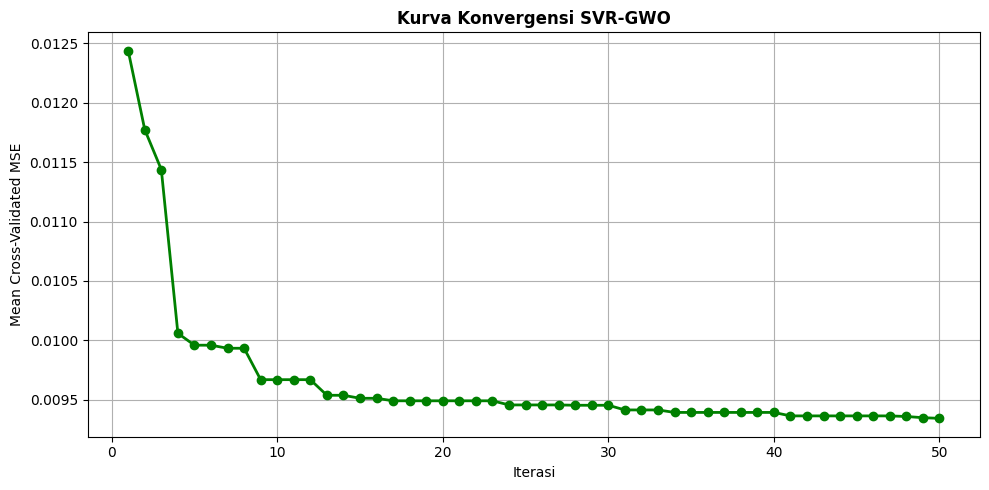

Grafik Konvergensi Tampil Sempurna!


In [ ]:
# GRAFIK KONVERGENSI
plt.figure(figsize=(10, 5))
plt.plot(range(1, max_iter + 1), convergence_curve, color='green', marker='o', linewidth=2)
plt.title('Kurva Konvergensi SVR-GWO', fontweight='bold')
plt.xlabel('Iterasi')
plt.ylabel('Mean Cross-Validated MSE') # <--- INI YANG DIREVISI
plt.grid(True)

plt.tight_layout()
plt.show()
print("Grafik Konvergensi Tampil Sempurna!")

# 12. Visualisasi Aktual vs Prediksi

---



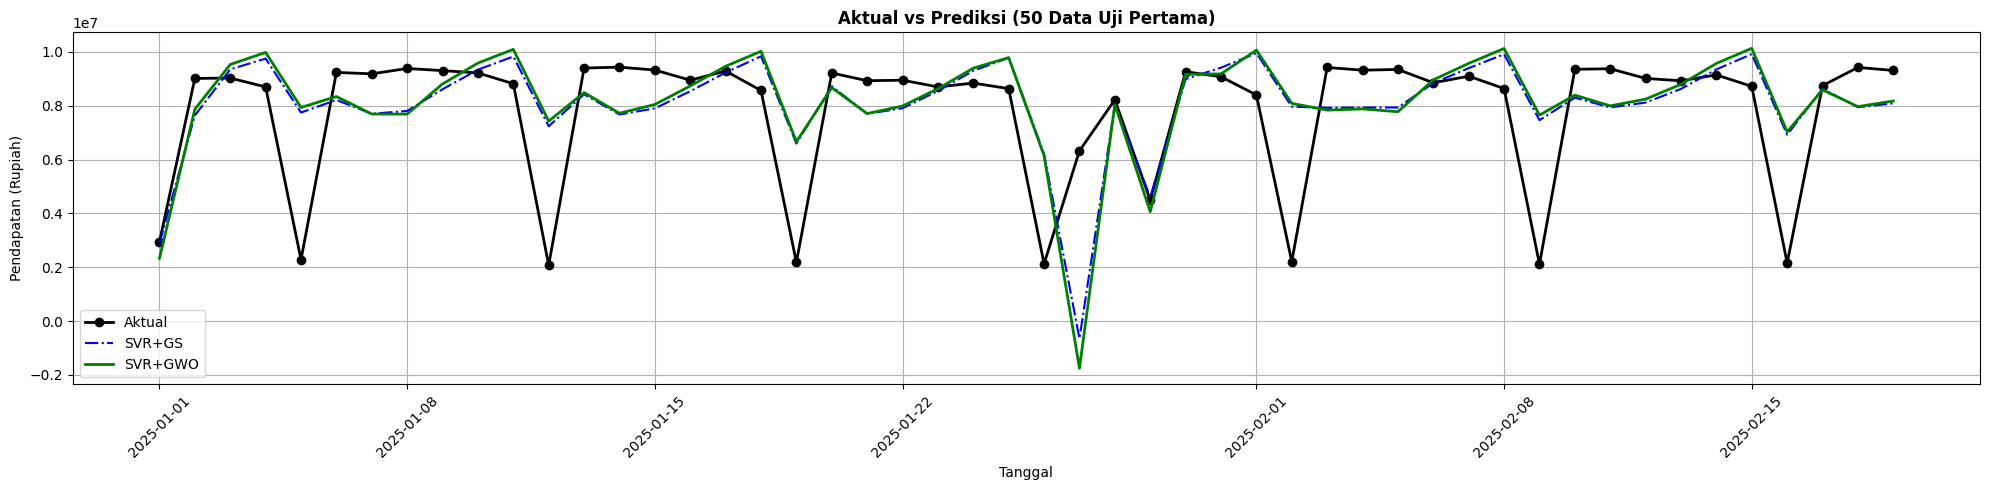

Grafik Aktual vs Prediksi Tampil Sempurna!


In [ ]:
# GRAFIK AKTUAL VS PREDIKSI
plt.figure(figsize=(20, 5))
batas = 50
tanggal_test = df_test['Tanggal'].values[:batas]

plt.plot(tanggal_test, y_test_asli[:batas], label='Aktual', color='black', marker='o', linewidth=2)
plt.plot(tanggal_test, y_pred_gs_test[:batas], label='SVR+GS', color='blue', linestyle='-.')
plt.plot(tanggal_test, y_pred_gwo_test[:batas], label='SVR+GWO', color='green', linestyle='-', linewidth=2)

plt.title('Aktual vs Prediksi (50 Data Uji Pertama)', fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Pendapatan (Rupiah)') # <--- INI YANG DIREVISI
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()
print("Grafik Aktual vs Prediksi Tampil Sempurna!")

# 13. Feature Importance

---



 ANALISIS FEATURE IMPORTANCE (GWO MODEL)
Menghitung variabel apa yang paling mempengaruhi pendapatan parkir...



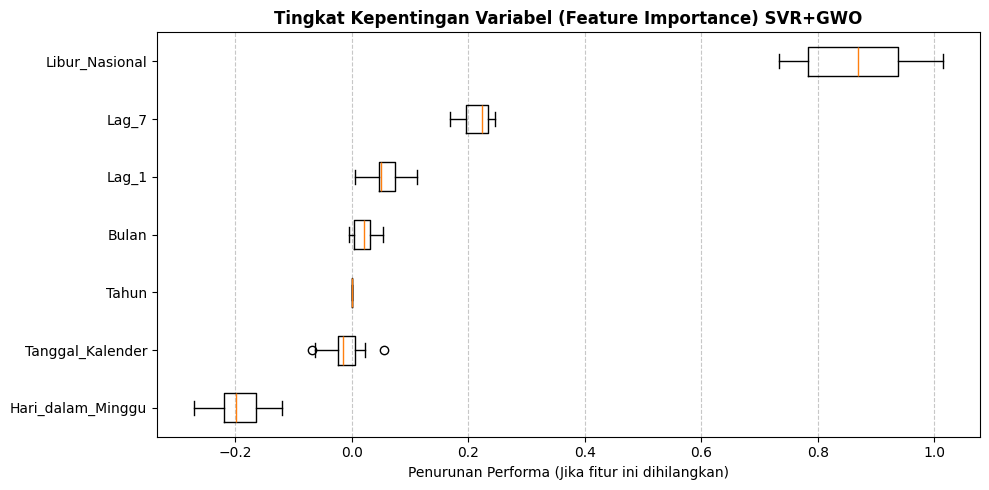

💡 CARA BACA:
Fitur yang berada paling ATAS adalah fitur yang PALING MEMPENGARUHI jumlah pendapatan retribusi parkir.


In [ ]:
from sklearn.inspection import permutation_importance

print("="*50)
print(" ANALISIS FEATURE IMPORTANCE (GWO MODEL)")
print("="*50)
print("Menghitung variabel apa yang paling mempengaruhi pendapatan parkir...\n")

# Melakukan permutasi untuk melihat seberapa hancur akurasi jika suatu fitur diacak
result_importance = permutation_importance(svr_gwo, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Mengurutkan fitur dari yang paling penting ke yang tidak penting
sorted_idx = result_importance.importances_mean.argsort()

plt.figure(figsize=(10, 5))
plt.boxplot(result_importance.importances[sorted_idx].T, vert=False, labels=np.array(fitur)[sorted_idx])
plt.title("Tingkat Kepentingan Variabel (Feature Importance) SVR+GWO", fontweight='bold')
plt.xlabel("Penurunan Performa (Jika fitur ini dihilangkan)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("💡 CARA BACA:")
print("Fitur yang berada paling ATAS adalah fitur yang PALING MEMPENGARUHI jumlah pendapatan retribusi parkir.")

# 14. Analisis Residual


---





 ANALISIS RESIDUAL ERROR (SVR+GWO)


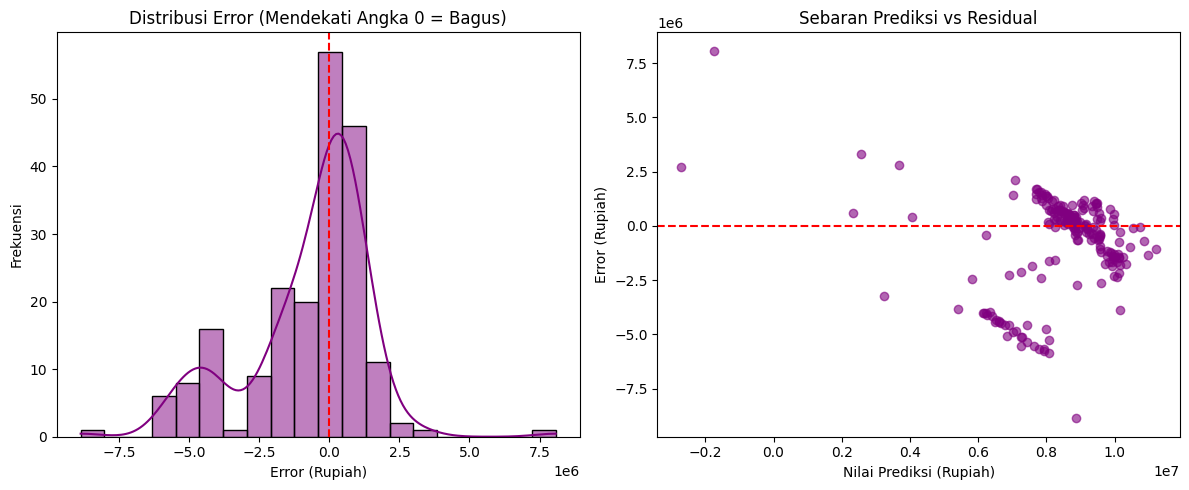

💡 CARA BACA:
Jika sebaran bentuk loncengnya (histogram) berpusat di garis merah (angka 0),
Artinya tebakan SVR + GWO kamu sangat stabil dan bebas dari bias ekstrim!


In [ ]:
import seaborn as sns

print("="*50)
print(" ANALISIS RESIDUAL ERROR (SVR+GWO)")
print("="*50)

# Menghitung selisih antara tebakan dan aslinya
residual_gwo = y_test_asli - y_pred_gwo_test

plt.figure(figsize=(12, 5))

# Plot 1: Sebaran Residual (Histogram)
plt.subplot(1, 2, 1)
sns.histplot(residual_gwo, kde=True, color='purple', bins=20)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribusi Error (Mendekati Angka 0 = Bagus)')
plt.xlabel('Error (Rupiah)')
plt.ylabel('Frekuensi')

# Plot 2: Tebakan vs Error (Scatter)
plt.subplot(1, 2, 2)
plt.scatter(y_pred_gwo_test, residual_gwo, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Sebaran Prediksi vs Residual')
plt.xlabel('Nilai Prediksi (Rupiah)')
plt.ylabel('Error (Rupiah)')

plt.tight_layout()
plt.show()

print("💡 CARA BACA:")
print("Jika sebaran bentuk loncengnya (histogram) berpusat di garis merah (angka 0),")
print("Artinya tebakan SVR + GWO kamu sangat stabil dan bebas dari bias ekstrim!")